Proses Eleminasi Data sentimen duplikasi, null, dan kalimat tidak relevan :


1. Bahasa
2. Negara
3. kalimat (Crypto, Judi, iklan, )
4. Duplikasi

Kerapian data.


In [ ]:
import pandas as pd

# 1. Memuat Data
# Membaca file CSV yang Anda unggah ke dalam sistem
df = pd.read_csv(
    r"G:\My Drive\skripsi\proje\proje\data\processed\dataset_hasil 102.csv"
)

# 2. Mengecek Kondisi Awal
# Menghitung total baris sebelum proses pembersihan dilakukan
total_sebelum = len(df)

# 3. Mencari Duplikasi
# Memindai khusus pada kolom 'id' untuk melihat apakah ada nilai yang berulang
jumlah_duplikat = df.duplicated(subset=["id"]).sum()

# 4. Mengeliminasi Duplikasi
# Membuang baris yang duplikat dan hanya menyimpan satu data asli (data pertama yang muncul)
df_bersih = df.drop_duplicates(subset=["id"])

# 5. Mengecek Kondisi Akhir
# Menghitung total baris setelah duplikasi dibuang
total_setelah = len(df_bersih)

# 6. Menampilkan Laporan Hasil
print(f"Total baris awal: {total_sebelum}")
print(f"Jumlah duplikasi yang ditemukan: {jumlah_duplikat}")
print(f"Total baris setelah dibersihkan: {total_setelah}")

Total baris awal: 23985
Jumlah duplikasi yang ditemukan: 0
Total baris setelah dibersihkan: 23985


In [ ]:
import pandas as pd
import re

# ==========================================
# 1. MEMUAT DATA (Menggunakan Raw String 'r')
# ==========================================
# Huruf 'r' di depan kutip mencegah eror akibat karakter garis miring terbalik (\) di Windows
df = pd.read_csv(
    r"G:\My Drive\skripsi\proje\proje\data\processed\dataset_hasil 102.csv"
)

# ==========================================
# 2. MENANGANI MISSING VALUES (Tahap Terlewat)
# ==========================================
df = df.drop(
    columns=["views"], errors="ignore"
)  # Menghapus kolom views yang kosong total
df["name"] = df["name"].fillna("Unknown")  # Menambal 1 data name yang kosong

# ==========================================
# 3. STANDARISASI FORMAT DATA (DATA TYPING)
# ==========================================
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")
df["followers"] = pd.to_numeric(df["followers"], errors="coerce").fillna(0).astype(int)
df["likes"] = pd.to_numeric(df["likes"], errors="coerce").fillna(0).astype(int)
df["replies"] = pd.to_numeric(df["replies"], errors="coerce").fillna(0).astype(int)


# ==========================================
# 4. FUNGSI PEMBERSIHAN TEKS (TEXT CLEANING)
# ==========================================
def bersihkan_teks(teks):
    if not isinstance(teks, str):
        return ""

    teks = teks.lower()
    teks = re.sub(r"https?://\S+|www\.\S+", "", teks)
    teks = re.sub(r"@\w+", "", teks)
    teks = re.sub(r"#", "", teks)
    teks = re.sub(r"[^a-z0-9\s]", " ", teks)
    teks = re.sub(r"\s+", " ", teks).strip()

    return teks


# ==========================================
# 5. EKSEKUSI PEMBERSIHAN TEKS
# ==========================================
df["text_clean"] = df["text"].apply(bersihkan_teks)

# ==========================================
# 6. ELIMINASI BARIS YANG KOSONG SETELAH CLEANING
# ==========================================
# Membuang data yang kehilangan teks akibat pembersihan agar tidak merusak modeling
df = df[df["text_clean"] != ""]

# ==========================================
# 7. MENYIMPAN HASIL AKHIR
# ==========================================
df.to_csv("dataset_hasil_102_siap_model.csv", index=False)

print(f"Proses selesai! Total data akhir yang siap digunakan: {len(df)} baris.")

C:\Users\EZRA\AppData\Local\Temp\ipykernel_1072\3870934197.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')


Proses selesai! Total data akhir yang siap digunakan: 23984 baris.


eleminasi bahasa asing dengan langdetec


Sistem sedang memindai bahasa pada puluhan ribu baris data. Mohon tunggu...
Mengekstraksi fitur teks dan menyusun plot...


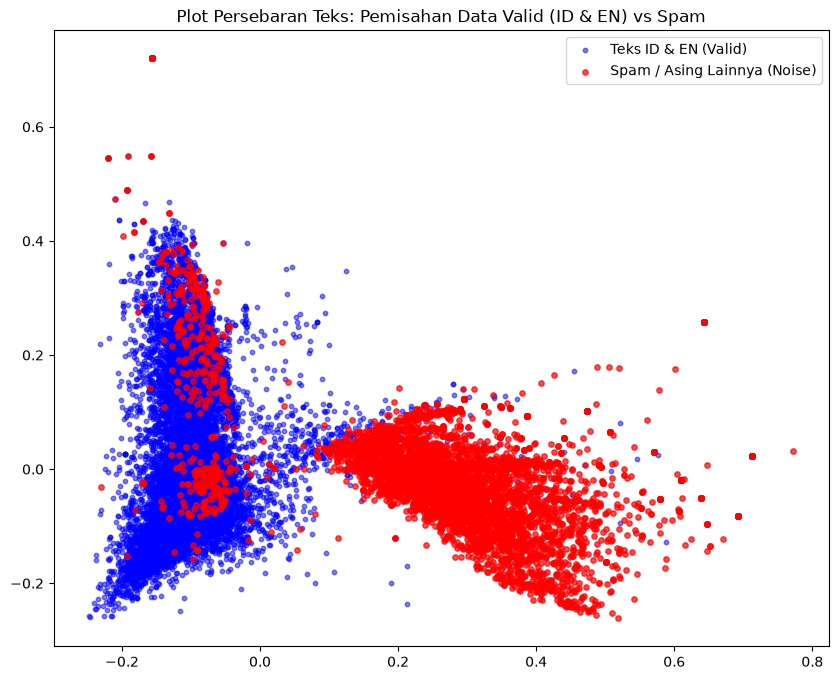


=== LAPORAN ELIMINASI BAHASA ASING (SPAM) ===
Total Baris Awal       : 23984
Dieliminasi (Selain ID&EN) : 5431 baris (Dibuang)
Total Baris Akhir      : 18553 baris (Disimpan)
Data bersih bahasa Indonesia & Inggris berhasil disimpan!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from langdetect import detect

# 1. MUAT DATA DAN CATAT TITIK AWAL
df = pd.read_csv(
    r"G:\My Drive\skripsi\proje\proje\data\processed\dataset_hasil_102_siap_model.csv"
)
jumlah_awal = len(df)


# 2. FUNGSI DETEKSI BAHASA
def deteksi_bahasa(teks):
    try:
        return detect(str(teks))  # Memastikan teks terbaca sebagai string
    except:
        return "unknown"


print("Sistem sedang memindai bahasa pada puluhan ribu baris data. Mohon tunggu...")
df["language"] = df["text_clean"].apply(deteksi_bahasa)

# 3. MENGHITUNG STATISTIK ELIMINASI SEMENTARA
# KUNCI PERUBAHAN: Menandai 'id' dan 'en' sebagai data valid
kondisi_valid = df["language"].isin(["id", "en"])

jumlah_valid = kondisi_valid.sum()
jumlah_asing_dibuang = jumlah_awal - jumlah_valid

# 4. PROSES TF-IDF & PCA (VISUALISASI)
print("Mengekstraksi fitur teks dan menyusun plot...")
vectorizer = TfidfVectorizer(max_features=1000)
X_tfidf = vectorizer.fit_transform(df["text_clean"].astype(str))

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_tfidf.toarray())

df["pca_x"] = X_pca[:, 0]
df["pca_y"] = X_pca[:, 1]

# Membuat Grafik
plt.figure(figsize=(10, 8))

# KUNCI PERUBAHAN: Memisahkan plot berdasarkan kondisi_valid
df_valid = df[kondisi_valid]
df_asing = df[~kondisi_valid]  # Tanda tilde (~) artinya kebalikan/selain data valid

plt.scatter(
    df_valid["pca_x"],
    df_valid["pca_y"],
    color="blue",
    label="Teks ID & EN (Valid)",
    alpha=0.5,
    s=10,
)
plt.scatter(
    df_asing["pca_x"],
    df_asing["pca_y"],
    color="red",
    label="Spam / Asing Lainnya (Noise)",
    alpha=0.7,
    s=15,
)

plt.title("Plot Persebaran Teks: Pemisahan Data Valid (ID & EN) vs Spam")
plt.legend()
plt.show()

# 5. EKSEKUSI ELIMINASI DAN CETAK LAPORAN
df_final = df_valid.drop(columns=["pca_x", "pca_y", "language"])
jumlah_akhir = len(df_final)

print("\n=== LAPORAN ELIMINASI BAHASA ASING (SPAM) ===")
print(f"Total Baris Awal       : {jumlah_awal}")
print(f"Dieliminasi (Selain ID&EN) : {jumlah_asing_dibuang} baris (Dibuang)")
print(f"Total Baris Akhir      : {jumlah_akhir} baris (Disimpan)")
print("=============================================")

# 6. SIMPAN HASIL AKHIR
df_final.to_csv(
    r"G:\My Drive\skripsi\proje\proje\data\processed\dataset_102_valid_id_en.csv",
    index=False,
)
print("Data bersih bahasa Indonesia & Inggris berhasil disimpan!")

Aspek pembersihan:

1. Validitas ID

2. Duplikasi ID

3. Validitas timestamp

4. Pembersihan entitas HTML

5. Penghapusan noise (spam, judol, promo, dll.)

6. Normalisasi teks (penghapusan URL, mention, hashtag, spasi, lowercasing)

7. Penghapusan teks kosong setelah normalisasi

8. Deduplikasi teks berbasis template bot (dengan jalur ganda: angka utuh untuk analisis, angka dinetralkan untuk deteksi duplikat bot)

9. Standarisasi kolom output (ganti created_at_dt menjadi created_at, hapus kolom lama)


In [ ]:
import pandas as pd
import html
import os

print("=" * 60)
print("MEMULAI PIPELINE PEMBERSIHAN DATA (FINAL MUTLAK - JALUR GANDA)")
print("=" * 60)

# =========================================================
# 1. BACA FILE INPUT
# =========================================================
input_file = (
    r"G:\My Drive\skripsi\proje\proje\data\processed\dataset_102_valid_id_en.csv"
)

if not os.path.exists(input_file):
    raise FileNotFoundError(f"File tidak ditemukan: {input_file}")

df = pd.read_csv(input_file, dtype={"id": str})
total_raw = len(df)

print(f"\n📂 File input: {input_file}")
print(f"📂 Total baris mentah: {total_raw}")
print("\n📄 CONTOH 3 BARIS PERTAMA DATA MENTAH:")
cols_show = (
    ["id", "created_at", "text"] if "created_at" in df.columns else ["id", "text"]
)
print(df[cols_show].head(3).to_string())

# =========================================================
# 2. FILTER STRUKTURAL (ID & TIMESTAMP)
# =========================================================
print("\n" + "=" * 60)
print("FILTER STRUKTURAL (ID & TIMESTAMP)")
print("=" * 60)

# A. ID tidak valid
before_id = len(df)
df = df.dropna(subset=["id"])
df = df[df["id"].astype(str).str.fullmatch(r"\d{15,20}")].copy()
invalid_id_removed = before_id - len(df)
print(f"🆔 ID tidak valid dibuang: {invalid_id_removed} baris")

# B. Deduplikasi ID
before_dup_id = len(df)
df = df.drop_duplicates(subset=["id"]).copy()
dup_id_removed = before_dup_id - len(df)
print(f"🆔 Duplikat ID dibuang: {dup_id_removed} baris")

# C. Parsing timestamp fleksibel
bad_ts = 0
if "created_at" in df.columns:
    df["created_at_dt"] = pd.to_datetime(df["created_at"], errors="coerce", utc=True)
    bad_ts = df["created_at_dt"].isna().sum()
    df = df.dropna(subset=["created_at_dt"]).copy()
    print(f"🕒 Timestamp gagal parse dibuang: {bad_ts} baris")
else:
    print("⚠️  Kolom 'created_at' tidak ditemukan, lanjut tanpa filter waktu.")

df = df.reset_index(drop=True)
total_valid_structure = len(df)

# D. Unescape HTML
df["text"] = df["text"].fillna("").map(html.unescape)

# =========================================================
# 3. AUDIT & HAPUS NOISE
# =========================================================
noise_patterns = {
    "wa_number": r"(?i)\b(?:wa|whatsapp|w\.a)\b[\s:.]*(?:\+?62|08)\d{6,13}",
    "phone_raw": r"\b(?:\+?62|08)\d{8,13}\b",
    "telegram": r"(?i)(?:t\.me/|telegram)",
    "judol": r"(?i)\b(?:gacor|maxwin|judol|togel|rtp\s*slot|slot\s*(?:online|gacor|dana|pulsa|gampang\s*menang|zeus|mahjong)|scatter\s*hitam|bonus\s*new\s*member|depo\s*\d+k|agen\s*slot)\b",
    "promo": r"(?i)\b(?:giveaway|gratis\s*ongkir|diskon|promo\s*(?:spesial|menarik)?|open\s*order|jastip|cek\s*bio|link\s*di\s*bio|flash\s*sale|ready\s*stock|best\s*seller|murah\s*(?:banget|meriah)|cod\b|bayar\s*di\s*tempat)\b",
    "vip_grup": r"(?i)(?:join|gabung|daftar)\s*(?:grup|group|channel|kelas)?\s*(?:vip|telegram|wa|whatsapp)|signal\s*(?:saham|forex|trading)|kelas\s*trading|auto\s*profit|info\s*slot\s*gratis",
}

print("\n🔊 Distribusi Noise per Kategori:")
combined_noise_mask = pd.Series(False, index=df.index)
for label, pat in noise_patterns.items():
    m = df["text"].str.contains(pat, regex=True, na=False)
    combined_noise_mask |= m
    print(f"  {label:12s}: {m.sum():6d}  ({m.mean():.2%})")

total_noise = combined_noise_mask.sum()
print(
    f"\n📢 Total baris noise dibuang: {total_noise} ({total_noise / total_valid_structure:.2%})"
)
df = df[~combined_noise_mask].copy()

# =========================================================
# 4. NORMALISASI TEKS (JALUR GANDA)
# =========================================================
print("\n🔧 Normalisasi teks (vectorized, jalur ganda)...")

# Jalur 1: Angka utuh untuk analisis sentimen FinBERT
df["norm_text"] = (
    df["text"]
    .str.lower()
    .str.replace(r"https?://\S+|@\w+|#\w+", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Jalur 2: Angka dihancurkan menjadi '0' KHUSUS untuk membongkar trik bot
df["bot_check_text"] = df["norm_text"].str.replace(r"\d+", "0", regex=True)

# =========================================================
# 5. PEMBERSIHAN AKHIR (TEKS KOSONG & DUPLIKAT BOT)
# =========================================================
# A. Hapus teks kosong
before_empty = len(df)
df = df[df["norm_text"] != ""].copy()
empty_removed = before_empty - len(df)
print(f"📝 Setelah hapus teks kosong: {len(df)} (dibuang {empty_removed})")

# B. Simpan statistik bot sebelum dedup
top_bots = df["bot_check_text"].value_counts()

# C. Dedup berdasarkan bot_check_text
before_dup_text = len(df)
df_final = df.drop_duplicates(subset=["bot_check_text"]).copy()
dup_text_removed = before_dup_text - len(df_final)
print(f"🧹 Setelah dedup teks normal: {len(df_final)} (dibuang {dup_text_removed})")

# D. Buang kolom bantu bot_check_text
df_final = df_final.drop(columns=["bot_check_text"])

# =========================================================
# 6. STANDARISASI KOLOM & SIMPAN
# =========================================================
if "created_at" in df_final.columns and "created_at_dt" in df_final.columns:
    df_final = df_final.drop(columns=["created_at"])
    df_final = df_final.rename(columns={"created_at_dt": "created_at"})
elif "created_at_dt" in df_final.columns:
    df_final = df_final.rename(columns={"created_at_dt": "created_at"})

output_path = (
    r"G:\My Drive\skripsi\proje\proje\data\processed\dataset_bersih_part 1.csv"
)
df_final.to_csv(output_path, index=False)
print(f"\n💾 Dataset final disimpan di:\n   '{output_path}'")

# =========================================================
# 7. RINGKASAN AKHIR
# =========================================================
print("\n" + "=" * 60)
print("📊 RINGKASAN AKHIR PIPELINE")
print("=" * 60)
print(f"Total baris mentah awal     : {total_raw}")
print(f"Total data bersih akhir     : {len(df_final)}")
print(
    f"Total baris terbuang        : {total_raw - len(df_final)} ({(total_raw - len(df_final)) / total_raw:.2%})"
)
print("\nRincian Pembuangan:")
print(f"  - ID tidak valid          : {invalid_id_removed}")
print(f"  - Duplikat ID             : {dup_id_removed}")
print(f"  - Timestamp gagal         : {bad_ts}")
print(f"  - Noise (judol/spam/promo): {total_noise}")
print(f"  - Teks kosong             : {empty_removed}")
print(f"  - Duplikat bot template   : {dup_text_removed}")

if (top_bots > 1).any():
    print("\n🔁 Teks bot template paling sering diulang (setelah dedup ID):")
    for txt, cnt in top_bots.head(5).items():
        if cnt > 1:
            print(f"  [{cnt}x] {txt[:120]}")

print("\n✅ Pipeline final disepakati. Data murni siap analisis.")

MEMULAI PIPELINE PEMBERSIHAN DATA (FINAL MUTLAK - JALUR GANDA)

📂 File input: G:\My Drive\skripsi\proje\proje\data\processed\dataset_102_valid_id_en.csv
📂 Total baris mentah: 18553

📄 CONTOH 3 BARIS PERTAMA DATA MENTAH:
                    id                 created_at                                                                                                                                                                                                                                                                                                                                                                                                                                           text
0  1961349819189834042  2025-08-29 08:46:51+00:00                                                                                                                                                                                                       Hari ini full dengan huru hara negara, dari kampus,

Clean Tweets dalam konteks kalimat dan bahasa tahap 2.

Fitur Lengkap:

- Funnel 7 tahap saling eksklusif
- Cache agresif untuk fungsi berat (pembersihan, deteksi bahasa, normalisasi slang)
- Deduplikasi aman: dilakukan pada teks bersih SEBELUM normalisasi slang,
  sehingga dua tweet berbeda tidak dianggap copypasta hanya karena slang yang diseragamkan.
- Filter iklan/scam berbasis regex kontekstual (hard/soft pattern + konteks ajakan)
- Filter bahasa asing opsional (--no-lang-filter), dengan kamus ID_WORDS
  yang sudah diperkaya jargon pasar modal & ticker saham agar data organik tidak terbuang.
- Normalisasi slang: frasa multi-kata diproses lebih dulu, baru kata tunggal.
- Normalisasi angka & persentase opsional (--normalize-numbers).
- Threshold token: menggunakan \w+ (huruf + angka), minimal 2 token / 8 karakter,
  sehingga tweet pendek khas trader ("BBCA naik") tetap lolos.
- Validasi rentang waktu 2020-2026 (menjaga konsistensi temporal dengan IHSG).
- Output menyertakan text_clean_raw untuk keperluan debugging/verifikasi.
- Peringatan jika dataset final kosong.
- Input bisa berupa folder CSV atau satu file CSV.


In [ ]:
import argparse, glob, html, os, re, sys, unicodedata
import pandas as pd
from functools import lru_cache

# ------------------------------------------------------------------ Konstanta
TWITTER_EPOCH_MS = 1288834974657
CANON = [
    "id",
    "created_at",
    "username",
    "name",
    "followers",
    "verified",
    "text",
    "likes",
    "replies",
]
MIN_DATE = pd.Timestamp("2020-01-01", tz="UTC")
MAX_DATE = pd.Timestamp("2026-12-31", tz="UTC")

# ---------------------------------------------------------------- Regex Noise
RE_URL = re.compile(r"(?:https?://|www\.)\S+|pic\.twitter\.com/\S+", re.I)
RE_MENTION = re.compile(r"@\w+")
RE_HASHTAG = re.compile(r"#(\w+)")
RE_CASHTAG = re.compile(r"\$([A-Za-z]{2,6})\b")
RE_RT = re.compile(r"^\s*RT\b[:\s]*", re.I)
RE_EMOJI = re.compile(
    "[\U0001f000-\U0001faff\U00002600-\U000027bf\U0001f1e6-\U0001f1ff"
    "\U00002190-\U000021ff\U00002b00-\U00002bff️‍⃣❤™©®•▪-◾]+"
)
RE_CTRL = re.compile(r"[\x00-\x1f\x7f-\x9f​-‏⁠﻿]")
RE_CHAR3 = re.compile(r"(\w)\1{2,}")  # merahhh -> merah
RE_PUNCT2 = re.compile(r"([!?.,;:~*'\"-])\1+")  # !!! -> !
RE_WS = re.compile(r"\s+")
RE_URL_RESIDU = re.compile(r"\S*(?:https?:|t\.co/|\bwww\.)\S*", re.I)

# ---------------------------------------------------- Pola Spam / Iklan
RE_JUDOL_HARD = re.compile(
    r"\b(?:maxwin|anti\s*rungkad|scatter\s*hitam|rtp\s*(?:slot|live)"
    r"|slot\s*(?:online|gacor|deposit|pulsa)"
    r"|bo\s+terpercaya|link\s+alternatif|depo\s+(?:pulsa|minim))\b",
    re.I,
)
RE_JUDOL_SOFT = re.compile(r"\b(?:judol|judi\s*online|togel|gacor|slot)\b", re.I)
RE_AD_CTX = re.compile(
    r"(?:bonus\s+new\s+member|winrate|min(?:imal)?\s+depo|jp\s+paus"
    r"|link\s+(?:daftar|resmi)|(?:gabung|daftar)\s+sekarang"
    r"|wd\s+(?:cepat|lancar|aman|instan))",
    re.I,
)
RE_PROMO = re.compile(
    r"\b(?:giveaway|gratis\s*ongkir|free\s*ongkir|open\s*(?:order|po|jasa|reseller)"
    r"|jastip|wts|wtb|ready\s+stock|dm\s+for\s+order)\b",
    re.I,
)
RE_VIP = re.compile(
    r"(?:(?:join|gabung|daftar)\W{0,3}(?:grup|group|channel|telegram|kelas|member)"
    r"\W{0,15}(?:vip|premium|sinyal|signal)"
    r"|(?:sinyal|signal)\s+(?:saham|trading)\W{0,15}(?:vip|premium|join)"
    r"|kelas\s+(?:saham|trading)\W{0,20}(?:gratis|daftar|join|dibuka)|auto\s+profit"
    r"|dijamin\s+profit|profit\s+(?:konsisten|harian)\W{0,15}join)",
    re.I,
)
RE_SCAM = re.compile(
    r"(?:\b(?:wa|whatsapp|w\.a)\b\W{0,4}(?:\+?62|0?8)\d{6,}"
    r"|wa\.me/|api\.whatsapp\.com|t\.me/|telegram\.me/|\bjoin\s+tele(?:gram)?\b"
    r"|(?:hubungi|hub|kontak|contact|cp)\W{0,4}(?:\+?62|08)\d{6,}"
    r"|\b08\d{8,11}\b|\+62\s?8\d{2}[\s-]?\d{3,4}[\s-]?\d{3,5}"
    r"|\+\d{3}[\s-]?\d{2,3}[\s-]?\d{3}[\s-]?\d{3,4})",
    re.I,
)

# ------------------------------------------------- Kamus Normalisasi Slang
MULTI_WORD_SLANG = {
    "tancap gas": "naik cepat",
    "cut loss": "hentikan rugi",
    "profit taking": "ambil untung",
    "take profit": "ambil untung",
    "buy back": "beli kembali",
}
SINGLE_WORD_SLANG = {
    "yg": "yang",
    "krn": "karena",
    "dgn": "dengan",
    "tp": "tapi",
    "anjlokk": "anjlok",
    "anjlokkk": "anjlok",
    "naikk": "naik",
    "porto": "portofolio",
    "cuan": "untung",
    "boncos": "rugi",
    "klo": "kalau",
    "jd": "jadi",
    "bgt": "banget",
    "udh": "sudah",
    "gw": "saya",
    "lu": "kamu",
    "dr": "dari",
    "utk": "untuk",
    "jebol": "jatuh",
    "nyangkut": "terjebak",
    "terbang": "naik tinggi",
    "nyungsep": "turun tajam",
    "rebound": "naik kembali",
    "hr": "hari",
    "skrg": "sekarang",
    "trs": "terus",
}

# ---------------------------------------------------- Normalisasi Angka (Opsional)
RE_PERCENT = re.compile(r"(\d+[\.,]\d+)%")
RE_THOUSANDS = re.compile(r"(?<=\d)\.(?=\d{3})")
RE_RUPIAH = re.compile(r"\bRp\s?(\d[\d\.,]*)", re.I)


def normalize_numbers(text: str) -> str:
    """Seragamkan format angka & persentase agar model lebih mudah memahaminya."""
    t = RE_RUPIAH.sub(r"\1 rupiah", text)
    t = RE_PERCENT.sub(r"\1 persen", t)
    t = RE_THOUSANDS.sub("", t)  # 7.200 → 7200
    return t


# ------------------------------------------------------ Deteksi Bahasa Asing
ID_WORDS = {
    "yang",
    "yg",
    "dan",
    "di",
    "ke",
    "dari",
    "dr",
    "ini",
    "itu",
    "tidak",
    "tak",
    "gak",
    "ga",
    "nggak",
    "ngga",
    "engga",
    "untuk",
    "utk",
    "dengan",
    "dgn",
    "akan",
    "ada",
    "adalah",
    "saja",
    "aja",
    "sudah",
    "udah",
    "udh",
    "belum",
    "blm",
    "bisa",
    "bs",
    "karena",
    "krn",
    "kalau",
    "kalo",
    "klo",
    "lagi",
    "lg",
    "banget",
    "bgt",
    "saya",
    "aku",
    "gue",
    "gw",
    "kita",
    "kami",
    "kamu",
    "kalian",
    "dia",
    "mereka",
    "apa",
    "siapa",
    "kenapa",
    "gimana",
    "jadi",
    "jd",
    "tapi",
    "tp",
    "atau",
    "juga",
    "jg",
    "sih",
    "dong",
    "deh",
    "nih",
    "mau",
    "buat",
    "bikin",
    "kok",
    "masih",
    "msh",
    "sangat",
    "sekali",
    "hari",
    "pasar",
    "saham",
    "bursa",
    "rupiah",
    "naik",
    "turun",
    "merah",
    "hijau",
    "demo",
    "harga",
    "jual",
    "beli",
    "orang",
    "uang",
    "duit",
    "pak",
    "bang",
    "bapak",
    "ibu",
    "kan",
    "pun",
    "nya",
    "banyak",
    "semua",
    "kasih",
    "tau",
    "tahu",
    "dunia",
    "kemarin",
    "besok",
    "sekarang",
    "skrg",
    "terus",
    "trs",
    "makin",
    "kayak",
    "gitu",
    "gini",
    "memang",
    "emang",
    "biar",
    "sampai",
    "sampe",
    "cuma",
    "cuman",
    "doang",
    "paling",
    "lebih",
    "kurang",
    "tetap",
    "tetep",
    "harus",
    "mungkin",
    "malah",
    "kena",
    "murah",
    "mahal",
    "bagus",
    "jelek",
    "gede",
    "rakyat",
    "negara",
    "pemerintah",
    "presiden",
    "menteri",
    "dpr",
    "kok",
    "lah",
    "toh",
    "ternyata",
    "padahal",
    "pada",
    "tahun",
    "bakal",
    "usai",
    "resmi",
    "sebesar",
    "persen",
    "triliun",
    "miliar",
    "juta",
    "ribu",
    "hingga",
    "sejak",
    "saat",
    "telah",
    "oleh",
    "akibat",
    "emiten",
    "ekonomi",
    "laba",
    "anjlok",
    "melemah",
    "menguat",
    "seraya",
    "kayaknya",
    "sepertinya",
    # Jargon pasar modal (mencegah false-positive bahasa asing)
    "ihsg",
    "porto",
    "cuan",
    "boncos",
    "rebound",
    "ar",
    "arb",
    "ara",
    "lot",
    "bid",
    "offer",
    "bandar",
    "ritel",
    "bbca",
    "bbri",
    "bmri",
    "bbni",
    "goto",
    "tlkm",
    "bearish",
    "bullish",
}
EN_WORDS = {
    "the",
    "is",
    "are",
    "was",
    "were",
    "be",
    "been",
    "to",
    "of",
    "and",
    "in",
    "for",
    "on",
    "this",
    "that",
    "with",
    "will",
    "would",
    "has",
    "have",
    "had",
    "at",
    "by",
    "from",
    "but",
    "not",
    "you",
    "they",
    "we",
    "he",
    "she",
    "its",
    "what",
    "when",
    "why",
    "how",
    "about",
    "after",
    "before",
    "more",
    "than",
    "stocks",
    "price",
    "today",
    "market",
    "it",
    "just",
    "since",
    "there",
    "here",
    "now",
    "then",
    "very",
    "much",
    "many",
    "some",
    "any",
    "only",
    "still",
    "never",
    "always",
    "people",
    "money",
    "going",
    "know",
    "think",
    "good",
    "new",
    "make",
    "get",
    "got",
    "can",
    "cant",
    "dont",
    "really",
    "right",
    "well",
    "who",
    "which",
    "where",
    "while",
    "because",
    "could",
    "should",
    "them",
    "his",
    "her",
}
SW_WORDS = {
    "bei",
    "jumla",
    "rejareja",
    "mikoani",
    "kitambaa",
    "suruali",
    "shilingi",
    "elfu",
    "laki",
    "bidhaa",
    "karibu",
    "ununue",
    "mzigo",
    "kwa",
    "yako",
    "sasa",
    "ngapi",
    "jioni",
    "mpesa",
    "simu",
    "hapa",
    "huku",
    "wewe",
    "mimi",
    "yangu",
    "yake",
    "kama",
    "lakini",
    "ndio",
    "mzuri",
    "safi",
    "pia",
    "mafuta",
    "pesa",
    "watu",
    "mtu",
    "kitu",
    "bado",
    "tena",
    "kubwa",
    "ndogo",
    "nunua",
    "gari",
    "nyumba",
    "sana",
    "tsh",
    "ksh",
    "poa",
    "nyepesi",
    "mechi",
    "niko",
}
NYA_BLOCK = {"kenya", "fanya", "kufanya", "tunafanya", "wanafanya", "nyanya", "mnyanya"}
RE_SW_PHRASE = re.compile(
    r"\bbei\s+(?:ya|ni|gani|nafuu)\b|\bya\s+jumla\b|rejareja|\bm-?pesa\b"
    r"|\btsh\b|\bksh\b",
    re.I,
)
RE_NONLATIN = re.compile(r"[Ѐ-ӿ؀-ۿ฀-๿぀-ヿ一-鿿가-힯]")


@lru_cache(maxsize=20000)
def _is_foreign_cached(text: str) -> bool:
    letters = [c for c in text if c.isalpha()]
    if letters and len(RE_NONLATIN.findall(text)) / len(letters) > 0.3:
        return True
    tokens = [t for t in re.findall(r"[a-zA-Z]+", text.lower()) if len(t) > 1]
    id_strict = sum(t in ID_WORDS for t in tokens)
    id_hits = id_strict + sum(
        t.endswith("nya") and len(t) >= 5 and t not in NYA_BLOCK and t not in ID_WORDS
        for t in tokens
    )
    if id_strict <= 1 and RE_SW_PHRASE.search(text):
        return True
    if len(tokens) < 4:
        return False
    en_hits = sum(t in EN_WORDS for t in tokens)
    sw_hits = sum(t in SW_WORDS for t in tokens)
    return id_hits == 0 and (en_hits >= 2 or sw_hits >= 2)


def is_foreign(text: str) -> bool:
    return _is_foreign_cached(text)


# ---------------------------------------------------------- Pembersihan Dasar
@lru_cache(maxsize=30000)
def _clean_basic(raw: str) -> str:
    """Bersihkan noise → teks lowercase tanpa normalisasi slang."""
    t = html.unescape(html.unescape(str(raw)))
    t = RE_URL.sub(" ", t)
    t = RE_MENTION.sub(" ", t)
    t = RE_RT.sub("", t)
    t = RE_HASHTAG.sub(r"\1", t)
    t = RE_CASHTAG.sub(r"\1", t)
    t = unicodedata.normalize("NFKC", t)
    t = RE_EMOJI.sub(" ", t)
    t = t.translate(
        str.maketrans(
            {"‘": "'", "’": "'", "“": '"', "”": '"', "–": "-", "—": "-", "…": " "}
        )
    )
    t = RE_CTRL.sub(" ", t)
    t = RE_CHAR3.sub(r"\1", t)
    t = RE_PUNCT2.sub(r"\1", t)
    t = RE_URL_RESIDU.sub(" ", t)
    t = RE_WS.sub(" ", t).strip(" \t-–—:;,.|/\\'\"")
    return t.lower()


def clean_basic(raw: str) -> str:
    return _clean_basic(raw)


# ---------------------------------------------------------- Normalisasi Slang
@lru_cache(maxsize=20000)
def _apply_slang(text: str) -> str:
    """Terapkan kamus slang: frasa multi-kata dulu, baru kata tunggal."""
    t = text
    for phrase, replacement in MULTI_WORD_SLANG.items():
        t = re.sub(r"\b" + re.escape(phrase) + r"\b", replacement, t)
    words = t.split()
    normalized = [SINGLE_WORD_SLANG.get(w, w) for w in words]
    return " ".join(normalized)


def apply_slang(text: str) -> str:
    return _apply_slang(text)


# ------------------------------------------------------- Kunci Deduplikasi
def norm_key(text: str) -> str:
    return re.sub(r"[^a-z0-9]+", " ", text).strip()


# ---------------------------------------------------------------- Loader
def load_one(path: str) -> pd.DataFrame:
    """Muat satu file CSV (deteksi otomatis apakah ada header)."""
    with open(path, encoding="utf-8-sig") as fh:
        first = fh.readline().split(",")[0].strip().strip('"')
    headerless = bool(re.fullmatch(r"\d{15,20}", first))
    kw = dict(dtype=str, encoding="utf-8-sig", keep_default_na=False)
    if headerless:
        df = pd.read_csv(
            path, header=None, names=CANON[:7] + ["views", "likes", "replies"], **kw
        )
    else:
        df = pd.read_csv(path, **kw)
    df = df.rename(columns={"tanggal_waktu": "created_at"})
    for c in CANON:
        if c not in df.columns:
            df[c] = ""
    return df[CANON]


def load_all(folder: str) -> pd.DataFrame:
    """Muat semua CSV dalam satu folder."""
    files = sorted(glob.glob(f"{folder}/*.csv"))
    if not files:
        sys.exit(f"Tidak ada CSV di {folder}")
    frames = [load_one(f) for f in files]
    return pd.concat(frames, ignore_index=True)


# --------------------------------------------------------------- Pipeline
def run(
    src: str,
    out: str,
    no_lang_filter: bool = False,
    normalize_numbers_flag: bool = False,
) -> None:
    """
    Jalankan pipeline pembersihan.
    src: path ke file CSV tunggal, atau folder berisi CSV.
    out: folder tujuan output.
    """
    # Cek eksistensi sumber
    if not os.path.exists(src):
        sys.exit(f"ERROR: Path tidak ditemukan: {src}")

    if os.path.isfile(src):
        print(f"Memproses file tunggal: {src}")
        df = load_one(src)
    elif os.path.isdir(src):
        print(f"Memproses semua CSV dalam folder: {src}")
        df = load_all(src)
    else:
        sys.exit(f"ERROR: {src} bukan file maupun folder.")

    funnel = [("Data mentah hasil pengumpulan", len(df))]
    rejected = []

    def drop(mask, alasan, label):
        nonlocal df
        bad = df[mask].copy()
        if len(bad):
            bad["alasan"] = alasan
            rejected.append(bad)
        df = df[~mask].copy()
        funnel.append((label, -len(bad)))

    # 1. Struktur tidak valid
    df["text"] = df["text"].fillna("")
    drop(
        ~df["id"].str.fullmatch(r"\d{15,20}", na=False)
        | (df["text"].str.strip() == ""),
        "struktur_tidak_valid",
        "Id/teks tidak valid",
    )

    # Timestamp + validasi rentang 2020–2026
    df["created_at_utc"] = pd.to_datetime(
        (df["id"].astype("int64").to_numpy() >> 22) + TWITTER_EPOCH_MS,
        unit="ms",
        utc=True,
    )
    drop(
        (df["created_at_utc"] < MIN_DATE) | (df["created_at_utc"] > MAX_DATE),
        "tanggal_di_luar_rentang",
        "Tanggal di luar 2020-2026",
    )
    df["tanggal_wib"] = (df["created_at_utc"] + pd.Timedelta(hours=7)).dt.date

    # 2. Duplikat ID (simpan yang metadata-nya paling lengkap)
    df["meta"] = (df["verified"].str.len() > 0).astype(int) + (
        df["followers"].str.len() > 0
    ).astype(int)
    df = df.sort_values(["id", "meta"], ascending=[True, False])
    drop(df.duplicated("id", keep="first"), "duplikat_id", "Duplikat ID")

    # 3. Pembersihan dasar → untuk deduplikasi teks (AMAN, sebelum slang)
    df["text_clean_raw"] = df["text"].map(clean_basic)
    df = df.sort_values("created_at_utc")
    df["tkey"] = df["text_clean_raw"].map(norm_key)
    drop(
        df.duplicated("tkey", keep="first") & (df["tkey"] != ""),
        "duplikat_teks",
        "Duplikat teks (copypasta)",
    )

    # 4. Deteksi iklan & scam pada teks mentah
    raw_text = df["text"].map(lambda x: html.unescape(html.unescape(str(x))))
    is_iklan = (
        raw_text.str.contains(RE_JUDOL_HARD)
        | (raw_text.str.contains(RE_JUDOL_SOFT) & raw_text.str.contains(RE_AD_CTX))
        | raw_text.str.contains(RE_PROMO)
        | raw_text.str.contains(RE_VIP)
    )
    drop(is_iklan, "iklan_promosi_judol", "Iklan / promosi / judi online")
    drop(
        raw_text.loc[df.index].str.contains(RE_SCAM),
        "scam_kontak",
        "Scam kontak (WA/telepon/Telegram)",
    )
    del raw_text

    # 5. Bahasa asing (pada teks bersih sebelum slang)
    if not no_lang_filter:
        drop(
            df["text_clean_raw"].map(is_foreign),
            "bahasa_asing",
            "Bahasa asing (non-Indonesia)",
        )

    # 6. Normalisasi slang → text_clean_bert final
    df["text_clean_bert"] = df["text_clean_raw"].map(apply_slang)

    # 7. Normalisasi angka (opsional, via --normalize-numbers)
    if normalize_numbers_flag:
        df["text_clean_bert"] = df["text_clean_bert"].map(normalize_numbers)

    # 8. Filter terlalu pendek — menggunakan \w+ agar angka juga dihitung token
    tokens = df["text_clean_bert"].str.findall(r"\w+").str.len()
    drop(
        (tokens < 2) | (df["text_clean_bert"].str.len() < 8),
        "terlalu_pendek",
        "Terlalu pendek pasca-pembersihan",
    )

    # Peringatan jika dataset final kosong
    if len(df) == 0:
        print(
            "PERINGATAN: Tidak ada data yang tersisa setelah pembersihan. Proses dihentikan."
        )
        sys.exit(0)

    # ------------------------------------------------------------- Output
    df["verified"] = df["verified"].str.lower().map({"true": True, "false": False})
    df["followers"] = pd.to_numeric(df["followers"], errors="coerce").astype("Int64")
    for c in ("likes", "replies"):
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype("Int64")

    final_cols = [
        "id",
        "tanggal_wib",
        "username",
        "followers",
        "verified",
        "likes",
        "replies",
        "text_clean_raw",
        "text_clean_bert",
    ]
    df = df.sort_values("created_at_utc")[final_cols]
    df.to_csv(
        f"{out}/A dataset_sentimen_bersih_bert.csv", index=False, encoding="utf-8-sig"
    )

    # Data terbuang
    rej = pd.concat(rejected, ignore_index=True) if rejected else pd.DataFrame()
    if len(rej):
        rej["text"] = rej["text"].map(lambda x: RE_WS.sub(" ", str(x)).strip())
        rej[["id", "username", "alasan", "text"]].to_csv(
            f"{out}/A data_dibuang.csv", index=False, encoding="utf-8-sig"
        )

    # Laporan
    lines = [
        "# Laporan Pembersihan Data Sentimen\n",
        "| No | Tahapan Penyaringan | Perubahan | Sisa |",
        "|---|---|---|---|",
    ]
    total = funnel[0][1]
    lines.append(f"| 1 | {funnel[0][0]} | — | {total:,} |")
    for i, (label, delta) in enumerate(funnel[1:], start=2):
        total += delta
        lines.append(f"| {i} | {label} | {delta:,} | {total:,} |")
    lines += [
        f"\n- Rentang data (WIB): {df['tanggal_wib'].min()} s.d. {df['tanggal_wib'].max()}",
        f"- Jumlah hari kalender terisi: {df['tanggal_wib'].nunique()}",
        f"- Akun unik: {df['username'].nunique():,}",
        f"- Verified True/False/tidak diketahui: "
        f"{int((df['verified'] == True).sum()):,} / {int((df['verified'] == False).sum()):,} / "
        f"{int(df['verified'].isna().sum()):,}",
    ]
    report = "\n".join(lines)
    print(report)
    with open(f"{out}/A laporan_pembersihan.md", "w", encoding="utf-8") as fh:
        fh.write(report)


if __name__ == "__main__":
    # ==================== HARDCODE PATH FILE KAMU ====================
    INPUT_FILE = (
        r"G:\My Drive\skripsi\proje\proje\data\processed\dataset_bersih_part 1.csv"
    )
    OUTPUT_DIR = r"G:\My Drive\skripsi\proje\proje\data\processed"

    # Pastikan file input ada sebelum menjalankan
    if not os.path.exists(INPUT_FILE):
        print(f"FILE TIDAK DITEMUKAN: {INPUT_FILE}")
        print("Pastikan path sudah benar dan file tersedia.")
        sys.exit(1)

    run(INPUT_FILE, OUTPUT_DIR)

Memproses file tunggal: G:\My Drive\skripsi\proje\proje\data\processed\dataset_bersih_part 1.csv
# Laporan Pembersihan Data Sentimen

| No | Tahapan Penyaringan | Perubahan | Sisa |
|---|---|---|---|
| 1 | Data mentah hasil pengumpulan | — | 17,992 |
| 2 | Id/teks tidak valid | 0 | 17,992 |
| 3 | Tanggal di luar 2020-2026 | 0 | 17,992 |
| 4 | Duplikat ID | 0 | 17,992 |
| 5 | Duplikat teks (copypasta) | -59 | 17,933 |
| 6 | Iklan / promosi / judi online | -2 | 17,931 |
| 7 | Scam kontak (WA/telepon/Telegram) | -5 | 17,926 |
| 8 | Bahasa asing (non-Indonesia) | -302 | 17,624 |
| 9 | Terlalu pendek pasca-pembersihan | 0 | 17,624 |

- Rentang data (WIB): 2025-06-01 s.d. 2025-10-31
- Jumlah hari kalender terisi: 153
- Akun unik: 5,133
- Verified True/False/tidak diketahui: 9,411 / 8,213 / 0


# 2.1**Okeee** ini konteks pembersihan dengan cara yang kedua.


In [ ]:
import argparse, glob, html, os, re, sys, unicodedata
import pandas as pd
from functools import lru_cache

# ------------------------------------------------------------------ Konstanta
TWITTER_EPOCH_MS = 1288834974657
CANON = [
    "id",
    "created_at",
    "username",
    "name",
    "followers",
    "verified",
    "text",
    "likes",
    "replies",
]
MIN_DATE = pd.Timestamp("2020-01-01", tz="UTC")
MAX_DATE = pd.Timestamp("2026-12-31", tz="UTC")

# ---------------------------------------------------------------- Regex Noise
RE_URL = re.compile(r"(?:https?://|www\.)\S+|pic\.twitter\.com/\S+", re.I)
RE_MENTION = re.compile(r"@\w+")
RE_HASHTAG = re.compile(r"#(\w+)")
RE_CASHTAG = re.compile(r"\$([A-Za-z]{2,6})\b")
RE_RT = re.compile(r"^\s*RT\b[:\s]*", re.I)
RE_EMOJI = re.compile(
    "[\U0001f000-\U0001faff\U00002600-\U000027bf\U0001f1e6-\U0001f1ff"
    "\U00002190-\U000021ff\U00002b00-\U00002bff️‍⃣❤™©®•▪-◾]+"
)
RE_CTRL = re.compile(r"[\x00-\x1f\x7f-\x9f​-‏⁠﻿]")
RE_CHAR3 = re.compile(r"(\w)\1{2,}")  # merahhh -> merah
RE_PUNCT2 = re.compile(r"([!?.,;:~*'\"-])\1+")  # !!! -> !
RE_WS = re.compile(r"\s+")
RE_URL_RESIDU = re.compile(r"\S*(?:https?:|t\.co/|\bwww\.)\S*", re.I)

# ---------------------------------------------------- Pola Spam / Iklan
RE_JUDOL_HARD = re.compile(
    r"\b(?:maxwin|anti\s*rungkad|scatter\s*hitam|rtp\s*(?:slot|live)"
    r"|slot\s*(?:online|gacor|deposit|pulsa)"
    r"|bo\s+terpercaya|link\s+alternatif|depo\s+(?:pulsa|minim))\b",
    re.I,
)
RE_JUDOL_SOFT = re.compile(r"\b(?:judol|judi\s*online|togel|gacor|slot)\b", re.I)
RE_AD_CTX = re.compile(
    r"(?:bonus\s+new\s+member|winrate|min(?:imal)?\s+depo|jp\s+paus"
    r"|link\s+(?:daftar|resmi)|(?:gabung|daftar)\s+sekarang"
    r"|wd\s+(?:cepat|lancar|aman|instan))",
    re.I,
)
RE_PROMO = re.compile(
    r"\b(?:giveaway|gratis\s*ongkir|free\s*ongkir|open\s*(?:order|po|jasa|reseller)"
    r"|jastip|wts|wtb|ready\s+stock|dm\s+for\s+order)\b",
    re.I,
)
RE_VIP = re.compile(
    r"(?:(?:join|gabung|daftar)\W{0,3}(?:grup|group|channel|telegram|kelas|member)"
    r"\W{0,15}(?:vip|premium|sinyal|signal)"
    r"|(?:sinyal|signal)\s+(?:saham|trading)\W{0,15}(?:vip|premium|join)"
    r"|kelas\s+(?:saham|trading)\W{0,20}(?:gratis|daftar|join|dibuka)|auto\s+profit"
    r"|dijamin\s+profit|profit\s+(?:konsisten|harian)\W{0,15}join)",
    re.I,
)
RE_SCAM = re.compile(
    r"(?:\b(?:wa|whatsapp|w\.a)\b\W{0,4}(?:\+?62|0?8)\d{6,}"
    r"|wa\.me/|api\.whatsapp\.com|t\.me/|telegram\.me/|\bjoin\s+tele(?:gram)?\b"
    r"|(?:hubungi|hub|kontak|contact|cp)\W{0,4}(?:\+?62|08)\d{6,}"
    r"|\b08\d{8,11}\b|\+62\s?8\d{2}[\s-]?\d{3,4}[\s-]?\d{3,5}"
    r"|\+\d{3}[\s-]?\d{2,3}[\s-]?\d{3}[\s-]?\d{3,4})",
    re.I,
)
RE_SPAM_TICKER = re.compile(r"(?:\b[a-z]{4}\b[\s,]+){5,}", re.I)
RE_BOT_REPORT = re.compile(
    r"(?:[-+]\d+[\.,]\d+\s*%){2,}|\b(?:climbers|gainers|losers|dips|extends)\b", re.I
)
RE_TRUNCATED = re.compile(r"\.{3,}\s*$|…\s*$")
RE_EKONOMI_WAJIB = re.compile(
    r"\b(?:ihsg|saham|investasi|rupiah|market|bursa|emiten|investor|trading|porto"
    r"|cuan|boncos|jkse|jci|ar|arb|ara|bandar|ritel)\b",
    re.I,
)

# ------------------------------------------------- Kamus Normalisasi Slang
MULTI_WORD_SLANG = {
    "tancap gas": "naik cepat",
    "cut loss": "hentikan rugi",
    "profit taking": "ambil untung",
    "take profit": "ambil untung",
    "buy back": "beli kembali",
}
SINGLE_WORD_SLANG = {
    "yg": "yang",
    "krn": "karena",
    "dgn": "dengan",
    "tp": "tapi",
    "anjlokk": "anjlok",
    "anjlokkk": "anjlok",
    "naikk": "naik",
    "porto": "portofolio",
    "cuan": "untung",
    "boncos": "rugi",
    "klo": "kalau",
    "jd": "jadi",
    "bgt": "banget",
    "udh": "sudah",
    "gw": "saya",
    "lu": "kamu",
    "dr": "dari",
    "utk": "untuk",
    "jebol": "jatuh",
    "nyangkut": "terjebak",
    "terbang": "naik tinggi",
    "nyungsep": "turun tajam",
    "rebound": "naik kembali",
    "hr": "hari",
    "skrg": "sekarang",
    "trs": "terus",
}


# ---------------------------------------------------- Normalisasi Angka (Opsional)
RE_PERCENT = re.compile(r"(\d+[\.,]\d+)%")
RE_THOUSANDS = re.compile(r"(?<=\d)\.(?=\d{3})")
RE_RUPIAH = re.compile(r"\bRp\s?(\d[\d\.,]*)", re.I)


def normalize_numbers(text: str) -> str:
    """Seragamkan format angka & persentase agar model lebih mudah memahaminya."""
    t = RE_RUPIAH.sub(r"\1 rupiah", text)
    t = RE_PERCENT.sub(r"\1 persen", t)
    t = RE_THOUSANDS.sub("", t)  # 7.200 → 7200
    return t


# ------------------------------------------------------ Deteksi Bahasa Asing
ID_WORDS = {
    "yang",
    "yg",
    "dan",
    "di",
    "ke",
    "dari",
    "dr",
    "ini",
    "itu",
    "tidak",
    "tak",
    "gak",
    "ga",
    "nggak",
    "ngga",
    "engga",
    "untuk",
    "utk",
    "dengan",
    "dgn",
    "akan",
    "ada",
    "adalah",
    "saja",
    "aja",
    "sudah",
    "udah",
    "udh",
    "belum",
    "blm",
    "bisa",
    "bs",
    "karena",
    "krn",
    "kalau",
    "kalo",
    "klo",
    "lagi",
    "lg",
    "banget",
    "bgt",
    "saya",
    "aku",
    "gue",
    "gw",
    "kita",
    "kami",
    "kamu",
    "kalian",
    "dia",
    "mereka",
    "apa",
    "siapa",
    "kenapa",
    "gimana",
    "jadi",
    "jd",
    "tapi",
    "tp",
    "atau",
    "juga",
    "jg",
    "sih",
    "dong",
    "deh",
    "nih",
    "mau",
    "buat",
    "bikin",
    "kok",
    "masih",
    "msh",
    "sangat",
    "sekali",
    "hari",
    "pasar",
    "saham",
    "bursa",
    "rupiah",
    "naik",
    "turun",
    "merah",
    "hijau",
    "demo",
    "harga",
    "jual",
    "beli",
    "orang",
    "uang",
    "duit",
    "pak",
    "bang",
    "bapak",
    "ibu",
    "kan",
    "pun",
    "nya",
    "banyak",
    "semua",
    "kasih",
    "tau",
    "tahu",
    "dunia",
    "kemarin",
    "besok",
    "sekarang",
    "skrg",
    "terus",
    "trs",
    "makin",
    "kayak",
    "gitu",
    "gini",
    "memang",
    "emang",
    "biar",
    "sampai",
    "sampe",
    "cuma",
    "cuman",
    "doang",
    "paling",
    "lebih",
    "kurang",
    "tetap",
    "tetep",
    "harus",
    "mungkin",
    "malah",
    "kena",
    "murah",
    "mahal",
    "bagus",
    "jelek",
    "gede",
    "rakyat",
    "negara",
    "pemerintah",
    "presiden",
    "menteri",
    "dpr",
    "kok",
    "lah",
    "toh",
    "ternyata",
    "padahal",
    "pada",
    "tahun",
    "bakal",
    "usai",
    "resmi",
    "sebesar",
    "persen",
    "triliun",
    "miliar",
    "juta",
    "ribu",
    "hingga",
    "sejak",
    "saat",
    "telah",
    "oleh",
    "akibat",
    "emiten",
    "ekonomi",
    "laba",
    "anjlok",
    "melemah",
    "menguat",
    "seraya",
    "kayaknya",
    "sepertinya",
    # Jargon pasar modal (mencegah false-positive bahasa asing)
    "ihsg",
    "porto",
    "cuan",
    "boncos",
    "rebound",
    "ar",
    "arb",
    "ara",
    "lot",
    "bid",
    "offer",
    "bandar",
    "ritel",
    "bbca",
    "bbri",
    "bmri",
    "bbni",
    "goto",
    "tlkm",
    "bearish",
    "bullish",
}
EN_WORDS = {
    "the",
    "is",
    "are",
    "was",
    "were",
    "be",
    "been",
    "to",
    "of",
    "and",
    "in",
    "for",
    "on",
    "this",
    "that",
    "with",
    "will",
    "would",
    "has",
    "have",
    "had",
    "at",
    "by",
    "from",
    "but",
    "not",
    "you",
    "they",
    "we",
    "he",
    "she",
    "its",
    "what",
    "when",
    "why",
    "how",
    "about",
    "after",
    "before",
    "more",
    "than",
    "stocks",
    "price",
    "today",
    "market",
    "it",
    "just",
    "since",
    "there",
    "here",
    "now",
    "then",
    "very",
    "much",
    "many",
    "some",
    "any",
    "only",
    "still",
    "never",
    "always",
    "people",
    "money",
    "going",
    "know",
    "think",
    "good",
    "new",
    "make",
    "get",
    "got",
    "can",
    "cant",
    "dont",
    "really",
    "right",
    "well",
    "who",
    "which",
    "where",
    "while",
    "because",
    "could",
    "should",
    "them",
    "his",
    "her",
}
SW_WORDS = {
    "bei",
    "jumla",
    "rejareja",
    "mikoani",
    "kitambaa",
    "suruali",
    "shilingi",
    "elfu",
    "laki",
    "bidhaa",
    "karibu",
    "ununue",
    "mzigo",
    "kwa",
    "yako",
    "sasa",
    "ngapi",
    "jioni",
    "mpesa",
    "simu",
    "hapa",
    "huku",
    "wewe",
    "mimi",
    "yangu",
    "yake",
    "kama",
    "lakini",
    "ndio",
    "mzuri",
    "safi",
    "pia",
    "mafuta",
    "pesa",
    "watu",
    "mtu",
    "kitu",
    "bado",
    "tena",
    "kubwa",
    "ndogo",
    "nunua",
    "gari",
    "nyumba",
    "sana",
    "tsh",
    "ksh",
    "poa",
    "nyepesi",
    "mechi",
    "niko",
}
NYA_BLOCK = {"kenya", "fanya", "kufanya", "tunafanya", "wanafanya", "nyanya", "mnyanya"}
RE_SW_PHRASE = re.compile(
    r"\bbei\s+(?:ya|ni|gani|nafuu)\b|\bya\s+jumla\b|rejareja|\bm-?pesa\b"
    r"|\btsh\b|\bksh\b",
    re.I,
)
RE_NONLATIN = re.compile(r"[Ѐ-ӿ؀-ۿ฀-๿぀-ヿ一-鿿가-힯]")


@lru_cache(maxsize=20000)
def _is_foreign_cached(text: str) -> bool:
    letters = [c for c in text if c.isalpha()]
    if letters and len(RE_NONLATIN.findall(text)) / len(letters) > 0.3:
        return True
    tokens = [t for t in re.findall(r"[a-zA-Z]+", text.lower()) if len(t) > 1]
    id_strict = sum(t in ID_WORDS for t in tokens)
    id_hits = id_strict + sum(
        t.endswith("nya") and len(t) >= 5 and t not in NYA_BLOCK and t not in ID_WORDS
        for t in tokens
    )
    if id_strict <= 1 and RE_SW_PHRASE.search(text):
        return True
    if len(tokens) < 4:
        return False
    en_hits = sum(t in EN_WORDS for t in tokens)
    sw_hits = sum(t in SW_WORDS for t in tokens)
    return id_hits == 0 and (en_hits >= 2 or sw_hits >= 2)


def is_foreign(text: str) -> bool:
    return _is_foreign_cached(text)


# ---------------------------------------------------------- Pembersihan Dasar
@lru_cache(maxsize=30000)
def _clean_basic(raw: str) -> str:
    """Bersihkan noise → teks lowercase tanpa normalisasi slang."""
    t = html.unescape(html.unescape(str(raw)))
    t = RE_URL.sub(" ", t)
    t = RE_MENTION.sub(" ", t)
    t = RE_RT.sub("", t)
    t = RE_HASHTAG.sub(r"\1", t)
    t = RE_CASHTAG.sub(r"\1", t)
    t = unicodedata.normalize("NFKC", t)
    t = RE_EMOJI.sub(" ", t)
    t = t.translate(
        str.maketrans(
            {"‘": "'", "’": "'", "“": '"', "”": '"', "–": "-", "—": "-", "…": " "}
        )
    )
    t = RE_CTRL.sub(" ", t)
    t = RE_CHAR3.sub(r"\1", t)
    t = RE_PUNCT2.sub(r"\1", t)
    t = RE_URL_RESIDU.sub(" ", t)
    t = RE_WS.sub(" ", t).strip(" \t-–—:;,.|/\\'\"")
    return t.lower()


def clean_basic(raw: str) -> str:
    return _clean_basic(raw)


# ---------------------------------------------------------- Normalisasi Slang
@lru_cache(maxsize=20000)
def _apply_slang(text: str) -> str:
    """Terapkan kamus slang: frasa multi-kata dulu, baru kata tunggal."""
    t = text
    for phrase, replacement in MULTI_WORD_SLANG.items():
        t = re.sub(r"\b" + re.escape(phrase) + r"\b", replacement, t)
    words = t.split()
    normalized = [SINGLE_WORD_SLANG.get(w, w) for w in words]
    return " ".join(normalized)


def apply_slang(text: str) -> str:
    return _apply_slang(text)


# ------------------------------------------------------- Kunci Deduplikasi
def norm_key(text: str) -> str:
    return re.sub(r"[^a-z0-9]+", " ", text).strip()


# ---------------------------------------------------------------- Loader
def load_one(path: str) -> pd.DataFrame:
    """Muat satu file CSV (deteksi otomatis apakah ada header)."""
    with open(path, encoding="utf-8-sig") as fh:
        first = fh.readline().split(",")[0].strip().strip('"')
    headerless = bool(re.fullmatch(r"\d{15,20}", first))
    kw = dict(dtype=str, encoding="utf-8-sig", keep_default_na=False)
    if headerless:
        df = pd.read_csv(
            path, header=None, names=CANON[:7] + ["views", "likes", "replies"], **kw
        )
    else:
        df = pd.read_csv(path, **kw)
    df = df.rename(columns={"tanggal_waktu": "created_at"})
    for c in CANON:
        if c not in df.columns:
            df[c] = ""
    return df[CANON]


def load_all(folder: str) -> pd.DataFrame:
    """Muat semua CSV dalam satu folder."""
    files = sorted(glob.glob(f"{folder}/*.csv"))
    if not files:
        sys.exit(f"Tidak ada CSV di {folder}")
    frames = [load_one(f) for f in files]
    return pd.concat(frames, ignore_index=True)


# --------------------------------------------------------------- Pipeline
def run(
    src: str,
    out: str,
    no_lang_filter: bool = False,
    normalize_numbers_flag: bool = False,
) -> None:
    """
    Jalankan pipeline pembersihan.
    src: path ke file CSV tunggal, atau folder berisi CSV.
    out: folder tujuan output.
    """
    # Cek eksistensi sumber
    if not os.path.exists(src):
        sys.exit(f"ERROR: Path tidak ditemukan: {src}")

    if os.path.isfile(src):
        print(f"Memproses file tunggal: {src}")
        df = load_one(src)
    elif os.path.isdir(src):
        print(f"Memproses semua CSV dalam folder: {src}")
        df = load_all(src)
    else:
        sys.exit(f"ERROR: {src} bukan file maupun folder.")

    funnel = [("Data mentah hasil pengumpulan", len(df))]
    rejected = []

    def drop(mask, alasan, label):
        nonlocal df
        bad = df[mask].copy()
        if len(bad):
            bad["alasan"] = alasan
            rejected.append(bad)
        df = df[~mask].copy()
        funnel.append((label, -len(bad)))

    # 1. Struktur tidak valid
    df["text"] = df["text"].fillna("")
    drop(
        ~df["id"].str.fullmatch(r"\d{15,20}", na=False)
        | (df["text"].str.strip() == ""),
        "struktur_tidak_valid",
        "Id/teks tidak valid",
    )

    # Timestamp + validasi rentang 2020–2026
    df["created_at_utc"] = pd.to_datetime(
        (df["id"].astype("int64").to_numpy() >> 22) + TWITTER_EPOCH_MS,
        unit="ms",
        utc=True,
    )
    drop(
        (df["created_at_utc"] < MIN_DATE) | (df["created_at_utc"] > MAX_DATE),
        "tanggal_di_luar_rentang",
        "Tanggal di luar 2020-2026",
    )
    df["tanggal_wib"] = (df["created_at_utc"] + pd.Timedelta(hours=7)).dt.date

    # 2. Duplikat ID (simpan yang metadata-nya paling lengkap)
    df["meta"] = (df["verified"].str.len() > 0).astype(int) + (
        df["followers"].str.len() > 0
    ).astype(int)
    df = df.sort_values(["id", "meta"], ascending=[True, False])
    drop(df.duplicated("id", keep="first"), "duplikat_id", "Duplikat ID")

    # 3. Pembersihan dasar → untuk deduplikasi teks (AMAN, sebelum slang)
    df["text_clean_raw"] = df["text"].map(clean_basic)
    df = df.sort_values("created_at_utc")
    df["tkey"] = df["text_clean_raw"].map(norm_key)
    drop(
        df.duplicated("tkey", keep="first") & (df["tkey"] != ""),
        "duplikat_teks",
        "Duplikat teks (copypasta)",
    )

    # =========================================================================
    # 4. Deteksi iklan & scam pada teks mentah (VERSI BARU & AMAN)
    # =========================================================================
    # Buat kolom sementara agar ukurannya otomatis sinkron dengan DataFrame
    df["temp_raw_text"] = df["text"].map(lambda x: html.unescape(html.unescape(str(x))))

    # a. Buang teks yang terpotong oleh limitasi scraper
    drop(
        df["temp_raw_text"].str.contains(RE_TRUNCATED),
        "teks_terpotong",
        "Teks tidak utuh (terpotong API)",
    )

    # b. Buang bot pelapor harga (fakta otomatis, bukan opini)
    drop(
        df["temp_raw_text"].str.contains(RE_BOT_REPORT),
        "laporan_bot",
        "Fakta pergerakan harga otomatis (bukan opini)",
    )

    # c. Buang spam deretan kode saham
    drop(
        df["temp_raw_text"].str.contains(RE_SPAM_TICKER),
        "spam_ticker",
        "Spam deretan kode saham",
    )

    # d. Wajib memiliki konteks ekonomi (isolasi dari tweet murni politik)
    drop(
        ~df["temp_raw_text"].str.contains(RE_EKONOMI_WAJIB),
        "luar_konteks",
        "Tidak mengandung kata kunci ekonomi/saham",
    )

    # e. Buang iklan judi/promo
    is_iklan = (
        df["temp_raw_text"].str.contains(RE_JUDOL_HARD)
        | (
            df["temp_raw_text"].str.contains(RE_JUDOL_SOFT)
            & df["temp_raw_text"].str.contains(RE_AD_CTX)
        )
        | df["temp_raw_text"].str.contains(RE_PROMO)
        | df["temp_raw_text"].str.contains(RE_VIP)
    )
    drop(is_iklan, "iklan_promosi_judol", "Iklan / promosi / judi online")

    # f. Buang scam kontak
    drop(
        df["temp_raw_text"].str.contains(RE_SCAM),
        "scam_kontak",
        "Scam kontak (WA/telepon/Telegram)",
    )

    # Bersihkan jejak: hapus kolom sementara karena sudah selesai dipakai
    df = df.drop(columns=["temp_raw_text"])
    # =========================================================================
    # 5. Bahasa asing (pada teks bersih sebelum slang)
    if not no_lang_filter:
        drop(
            df["text_clean_raw"].map(is_foreign),
            "bahasa_asing",
            "Bahasa asing (non-Indonesia)",
        )

    # 6. Normalisasi slang → text_clean_bert final
    df["text_clean_bert"] = df["text_clean_raw"].map(apply_slang)

    # 7. Normalisasi angka (opsional, via --normalize-numbers)
    if normalize_numbers_flag:
        df["text_clean_bert"] = df["text_clean_bert"].map(normalize_numbers)

    # 8. Filter terlalu pendek — menggunakan \w+ agar angka juga dihitung token
    tokens = df["text_clean_bert"].str.findall(r"\w+").str.len()
    drop(
        (tokens < 2) | (df["text_clean_bert"].str.len() < 8),
        "terlalu_pendek",
        "Terlalu pendek pasca-pembersihan",
    )

    # Peringatan jika dataset final kosong
    if len(df) == 0:
        print(
            "PERINGATAN: Tidak ada data yang tersisa setelah pembersihan. Proses dihentikan."
        )
        sys.exit(0)

    # ------------------------------------------------------------- Output
    df["verified"] = df["verified"].str.lower().map({"true": True, "false": False})
    df["followers"] = pd.to_numeric(df["followers"], errors="coerce").astype("Int64")
    for c in ("likes", "replies"):
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype("Int64")

    final_cols = [
        "id",
        "tanggal_wib",
        "username",
        "followers",
        "verified",
        "likes",
        "replies",
        "text_clean_raw",
        "text_clean_bert",
    ]
    df = df.sort_values("created_at_utc")[final_cols]
    df.to_csv(
        f"{out}/B dataset_sentimen_bersih_bert .csv", index=False, encoding="utf-8-sig"
    )

    # Data terbuang
    rej = pd.concat(rejected, ignore_index=True) if rejected else pd.DataFrame()
    if len(rej):
        rej["text"] = rej["text"].map(lambda x: RE_WS.sub(" ", str(x)).strip())
        rej[["id", "username", "alasan", "text"]].to_csv(
            f"{out}/B data_dibuang .csv", index=False, encoding="utf-8-sig"
        )

    # Laporan
    lines = [
        "# Laporan Pembersihan Data Sentimen\n",
        "| No | Tahapan Penyaringan | Perubahan | Sisa |",
        "|---|---|---|---|",
    ]
    total = funnel[0][1]
    lines.append(f"| 1 | {funnel[0][0]} | — | {total:,} |")
    for i, (label, delta) in enumerate(funnel[1:], start=2):
        total += delta
        lines.append(f"| {i} | {label} | {delta:,} | {total:,} |")
    lines += [
        f"\n- Rentang data (WIB): {df['tanggal_wib'].min()} s.d. {df['tanggal_wib'].max()}",
        f"- Jumlah hari kalender terisi: {df['tanggal_wib'].nunique()}",
        f"- Akun unik: {df['username'].nunique():,}",
        f"- Verified True/False/tidak diketahui: "
        f"{int((df['verified'] == True).sum()):,} / {int((df['verified'] == False).sum()):,} / "
        f"{int(df['verified'].isna().sum()):,}",
    ]
    report = "\n".join(lines)
    print(report)
    with open(f"{out}/B laporan_pembersihan.md", "w", encoding="utf-8") as fh:
        fh.write(report)


if __name__ == "__main__":
    # ==================== HARDCODE PATH FILE KAMU ====================
    INPUT_FILE = (
        r"G:\My Drive\skripsi\proje\proje\data\processed\dataset_bersih_part 1.csv"
    )
    OUTPUT_DIR = r"G:\My Drive\skripsi\proje\proje\data\processed"

    # Pastikan file input ada sebelum menjalankan
    if not os.path.exists(INPUT_FILE):
        print(f"FILE TIDAK DITEMUKAN: {INPUT_FILE}")
        print("Pastikan path sudah benar dan file tersedia.")
        sys.exit(1)

    run(INPUT_FILE, OUTPUT_DIR)

Memproses file tunggal: G:\My Drive\skripsi\proje\proje\data\processed\dataset_bersih_part 1.csv
# Laporan Pembersihan Data Sentimen

| No | Tahapan Penyaringan | Perubahan | Sisa |
|---|---|---|---|
| 1 | Data mentah hasil pengumpulan | — | 17,992 |
| 2 | Id/teks tidak valid | 0 | 17,992 |
| 3 | Tanggal di luar 2020-2026 | 0 | 17,992 |
| 4 | Duplikat ID | 0 | 17,992 |
| 5 | Duplikat teks (copypasta) | -59 | 17,933 |
| 6 | Teks tidak utuh (terpotong API) | -156 | 17,777 |
| 7 | Fakta pergerakan harga otomatis (bukan opini) | -205 | 17,572 |
| 8 | Spam deretan kode saham | -139 | 17,433 |
| 9 | Tidak mengandung kata kunci ekonomi/saham | -1,087 | 16,346 |
| 10 | Iklan / promosi / judi online | -1 | 16,345 |
| 11 | Scam kontak (WA/telepon/Telegram) | -1 | 16,344 |
| 12 | Bahasa asing (non-Indonesia) | -5 | 16,339 |
| 13 | Terlalu pendek pasca-pembersihan | 0 | 16,339 |

- Rentang data (WIB): 2025-06-01 s.d. 2025-10-31
- Jumlah hari kalender terisi: 153
- Akun unik: 4,650
- Verified True/

Konteks pembersihan.

1. **Hapus** teks dengan kata kunci: `crypto, kripto, bitcoin, btc, meme coin, bursa transfer, bursa taruhan, bola, pemain, liga`.
2. **Hapus** teks < 3 kata; **potong** teks > 512 token.
3. **Hapus** jika terdapat `bei tempi`, bahasa bukan `id`/`en`, atau _gibberish_ (huruf <60% / pengulangan >4).
4. **Simpan** hanya data dengan `tanggal_wib` di rentang **1 Maret – 31 Mei 2025**.


In [ ]:
import pandas as pd
import re
from pathlib import Path
from typing import Any, Optional

# =============================================================================
# KONSTANTA GLOBAL & PRE‑COMPILED REGEX (Performa Maksimal)
# =============================================================================
REQUIRED_COLS = ["text_clean_bert", "tanggal_wib"]

MAX_WORDS_FALLBACK = 400
MAX_TOKENS_TOKENIZER = 512

PATTERN_BLACKLIST = re.compile(
    r"\b(?:crypto|kripto|bitcoin|btc|"
    r"meme\s+coin|bursa\s+transfer|bursa\s+taruhan|"
    r"bola|pemain|liga)\b",
    re.IGNORECASE,
)
PATTERN_BEI_TEMPI = re.compile(r"\bbei tempi\b", re.IGNORECASE)
PATTERN_SYMBOLS = re.compile(r"[^\w\s]{5,}")
PATTERN_NONASCII = re.compile(r"[^\x00-\x7F]")
PATTERN_NOALPHA = re.compile(r"^[^A-Za-z]*$")


def final_cleaning_pipeline(
    file_path: str,
    output_path: str,
    start_date: str,
    end_date: str,
    tokenizer: Optional[Any] = None,
) -> None:
    """
    Pembersihan akhir dataset untuk ekstraksi fitur BERT (IHSG & Demonstrasi Politik).
    - Zero redundant regex overhead (literal counting pada spasi tunggal)
    - Inclusive Timezone‑safe Datetime Alignment (end_date + 23:59:59)
    - Safe tokenizer fallback & Fail‑Fast Protection
    """
    print("=== MEMULAI PEMBERSIHAN TAHAP AKHIR ===")

    # ── 1. Muat Data & Validasi ──────────────────────────────
    try:
        df = pd.read_csv(file_path, encoding="utf-8")
    except UnicodeDecodeError:
        df = pd.read_csv(file_path, encoding="ISO-8859-1")
    except FileNotFoundError:
        print(f"ERROR: File masukan {file_path} tidak ditemukan.")
        return

    if not set(REQUIRED_COLS).issubset(df.columns):
        print(f"ERROR: Kolom wajib tidak lengkap. Ditemukan: {list(df.columns)}")
        return

    df = df.dropna(subset=["text_clean_bert"]).copy()
    # Normalisasi spasi → cukup satu spasi antar kata
    df["text_clean_bert"] = (
        df["text_clean_bert"]
        .astype(str)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    total_awal = len(df)
    print(f"Total baris awal: {total_awal:,}\n")
    if df.empty:
        return _save_empty(output_path, total_awal, "Pemuatan Data Awal")

    # ── 2. Contextual Filtering ──────────────────────────────
    mask = df["text_clean_bert"].str.contains(PATTERN_BLACKLIST, regex=True, na=False)

    # FOKUS: Ekstrak dan simpan data yang terbuang ke CSV
    df_eliminated = df[mask]
    if not df_eliminated.empty:
        out_path_obj = Path(output_path)
        elim_path = (
            out_path_obj.parent
            / f"{out_path_obj.stem}_ELIMINATED_context{out_path_obj.suffix}"
        )
        df_eliminated.to_csv(elim_path, index=False, encoding="utf-8")
        print(f"INFO: Data terbuang disimpan di -> {elim_path.name}")

    # Lanjutkan sisa dataframe yang bersih
    df = df[~mask]
    print(
        f"[1] Contextual Filtering : {len(df_eliminated):,} dibuang. Sisa: {len(df):,}"
    )

    if df.empty:
        return _save_empty(output_path, total_awal, "Contextual Filtering")

    # ── 3. Length Boundary & Truncation ──────────────────────
    # Karena spasi sudah tunggal, cukup hitung karakter spasi
    word_counts = df["text_clean_bert"].str.count(" ") + 1
    mask_short = word_counts >= 3

    drop_short = len(df) - mask_short.sum()
    df = df[mask_short]
    if df.empty:
        print(f"[2] Length Boundary    : {drop_short:,} dibuang (<3 kata). Sisa: 0")
        return _save_empty(output_path, total_awal, "Length Boundary (<3 kata)")

    word_counts = word_counts[mask_short]
    truncated_count = 0

    if tokenizer is not None:
        if not (
            hasattr(tokenizer, "tokenize")
            and hasattr(tokenizer, "convert_tokens_to_string")
        ):
            raise TypeError("Tokenizer tidak memiliki metode standar HuggingFace.")

        over_limit = word_counts > MAX_TOKENS_TOKENIZER
        truncated_count = over_limit.sum()
        if truncated_count:
            # Safe tokenizer: cegah crash akibat karakter tak terduga
            def safe_tokenize(text: str) -> str:
                try:
                    return tokenizer.convert_tokens_to_string(
                        tokenizer.tokenize(text)[:MAX_TOKENS_TOKENIZER]
                    )
                except Exception:
                    return ""  # akan dibersihkan di bawah

            df.loc[over_limit, "text_clean_bert"] = df.loc[
                over_limit, "text_clean_bert"
            ].apply(safe_tokenize)
    else:
        over_limit = word_counts > MAX_WORDS_FALLBACK
        truncated_count = over_limit.sum()
        if truncated_count:
            df.loc[over_limit, "text_clean_bert"] = (
                df.loc[over_limit, "text_clean_bert"]
                .str.split()
                .str[:MAX_WORDS_FALLBACK]
                .str.join(" ")
            )

    # Buang hasil truncation yang kosong (gagal tokenisasi)
    df = df[df["text_clean_bert"] != ""]

    print(
        f"[2] Length Boundary    : {drop_short:,} dibuang (<3 kata), {truncated_count:,} dipotong. Sisa: {len(df):,}"
    )
    if df.empty:
        return _save_empty(
            output_path, total_awal, "Length Boundary (Pasca‑Truncation)"
        )

    # ── 4. Language Scrubbing ─────────────────────────────────
    sebelum = len(df)
    txt = df["text_clean_bert"]

    mask_bei = txt.str.contains(PATTERN_BEI_TEMPI, regex=True)
    mask_sym = txt.str.contains(PATTERN_SYMBOLS, regex=True)
    mask_noalpha = txt.str.contains(PATTERN_NOALPHA, regex=True)

    len_no_space = txt.str.len() - txt.str.count(" ")
    non_ascii = txt.str.count(PATTERN_NONASCII)
    mask_foreign = (non_ascii / len_no_space.clip(lower=1)) > 0.5

    full_mask = mask_bei | mask_sym | mask_noalpha | mask_foreign
    df = df[~full_mask]
    print(
        f"[3] Language Scrubbing : {sebelum - len(df):,} dibuang (asing/gibberish). Sisa: {len(df):,}"
    )
    if df.empty:
        return _save_empty(output_path, total_awal, "Language Scrubbing")

    # ── 5. Event Window Filtering (Inclusive Time Bounds) ─────
    sebelum = len(df)

    start_dt = pd.to_datetime(start_date)
    # Menjamin seluruh data pada hari terakhir ikut terambil
    end_dt = pd.to_datetime(end_date) + pd.Timedelta(hours=23, minutes=59, seconds=59)

    df["tanggal_wib"] = (
        pd.to_datetime(df["tanggal_wib"], errors="coerce", utc=True)
        .dt.tz_convert("Asia/Jakarta")
        .dt.tz_localize(None)
    )
    df = df.dropna(subset=["tanggal_wib"])

    mask_date = (df["tanggal_wib"] >= start_dt) & (df["tanggal_wib"] <= end_dt)
    df = df[mask_date]
    print(
        f"[4] Event Window       : {sebelum - len(df):,} dibuang (di luar periode). Sisa: {len(df):,}"
    )
    if df.empty:
        return _save_empty(output_path, total_awal, "Event Window Filtering")

    # ── 6. Simpan Hasil ──────────────────────────────────────
    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(output_path, index=False, encoding="utf-8")
    total_akhir = len(df)
    print(f"\n=== RINGKASAN AKHIR ===")
    print(f"Total awal  : {total_awal:,}")
    print(f"Total akhir : {total_akhir:,}")
    print(f"Terbuang    : {total_awal - total_akhir:,}")
    print(f"Output      : {output_path}")


def _save_empty(output_path: str, total_awal: int, stage: str) -> None:
    """Simpan skema CSV kosong saat pipeline terhenti lebih awal."""
    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(columns=REQUIRED_COLS).to_csv(output_path, index=False)
    print(f"\n⚠️  PIPELINE DIHENTIKAN di tahap '{stage}' – Data habis tereliminasi.")
    print(
        f"Total input awal: {total_awal:,} | File skema kosong disimpan di: {output_path}"
    )


if __name__ == "__main__":
    FILE_INPUT = r"G:\My Drive\skripsi\proje\proje\data\processed\A dataset_sentimen_bersih_bert.csv"
    FILE_OUTPUT = (
        r"G:\My Drive\skripsi\proje\proje\data\processed\A dataset_sentimen_1.1 .csv"
    )

    # Rentang waktu: 2 bulan sebelum dan 2 bulan sesudah puncak demonstrasi (Agustus 2025)
    START_DATE = "2025-06-01"
    END_DATE = "2025-10-31"

    final_cleaning_pipeline(FILE_INPUT, FILE_OUTPUT, START_DATE, END_DATE)

=== MEMULAI PEMBERSIHAN TAHAP AKHIR ===
Total baris awal: 17,624

INFO: Data terbuang disimpan di -> A dataset_sentimen_1.1 _ELIMINATED_context.csv
[1] Contextual Filtering : 1,480 dibuang. Sisa: 16,144
[2] Length Boundary    : 32 dibuang (<3 kata), 115 dipotong. Sisa: 16,112
[3] Language Scrubbing : 19 dibuang (asing/gibberish). Sisa: 16,093
[4] Event Window       : 0 dibuang (di luar periode). Sisa: 16,093

=== RINGKASAN AKHIR ===
Total awal  : 17,624
Total akhir : 16,093
Terbuang    : 1,531
Output      : G:\My Drive\skripsi\proje\proje\data\processed\A dataset_sentimen_1.1 .csv
